### Index Plot

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [49]:
nino_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/nino_true.npy')
nino_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/nino_saved.npy')
amo_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/amo_true.npy')
amo_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/amo_saved.npy')

nino_true2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/nino_true.npy')
nino_saved2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/nino_saved.npy')
amo_true2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/amo_true.npy')
amo_saved2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/amo_saved.npy')

nino_true3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/nino_true.npy')
nino_saved3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/nino_saved.npy')
amo_true3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/amo_true.npy')
amo_saved3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/amo_saved.npy')

In [69]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric(axs, row, col, true_data, indices_data, network_names, y_label, title, blend_names=None, label=None):
    if col == 2:
        clist = ["#3300EA","#D7191C","#DE7400","#00BD8E"]
    else:
        clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]
    N_plot = true_data.shape[1]
    for i, indices_i in enumerate(indices_data):
        if indices_i is not None:
            label_name = f"{network_names[i]}" if blend_names is None else f"{blend_names[i]}"
            axs[row, col].plot(np.arange(1, N_plot + 1), indices_i.mean(axis=0), c=clist[i], label=label_name)
            axs[row, col].fill_between(np.arange(1, N_plot + 1), 
                                       indices_i.mean(axis=0) - indices_i.std(axis=0), 
                                       indices_i.mean(axis=0) + indices_i.std(axis=0),
                                       ls="-",
                                       color=clist[i],
                                       alpha=0.2)
            
    axs[row, col].plot(np.arange(1, N_plot + 1), true_data.mean(axis=0), "--k", label="Ground Truth")
    if row == 0:
        axs[row, col].set_title(title, fontsize="15")
        axs[row, col].set_ylim([-1.9, 2.0])
    if row == 1:
        axs[row, col].set_xlabel(r"time $( days )$", fontsize="15")
        axs[row, col].set_ylim([-0.3,0.3])
    else:
        axs[row, col].tick_params(labelbottom=False)  # Remove x ticks in the first row
    if col == 0:
        axs[row, col].set_ylabel(y_label, fontsize="15")
    else:
        axs[row, col].tick_params(labelleft=False)  # Remove y ticks for columns except the first
    if row == 0 and col==0:
        axs[row, col].legend(bbox_to_anchor=(0, 1.2, 1, 0.2), loc="lower left", fancybox=True, fontsize="15", ncol=len(indices_data)+1)
    if row == 1 and col == 2:
        axs[row, col].legend(bbox_to_anchor=(-1.2, -0.8), loc="lower left", fancybox=True, fontsize="15", ncol=3)
    
    # Add the label at the bottom right corner
    if label:
        axs[row, col].text(0.95, 0.95, label, ha='center', va='center', transform=axs[row, col].transAxes, fontsize=12, fontweight='bold')

def plot_both_region_based_metric(
    network_names,
    region,
    save_str,
    output_dir,
    true_nino1,
    indices_nino1,
    true_nino2,
    indices_nino2,
    true_nino3,
    indices_nino3,
    true_amo1,
    indices_amo1,
    true_amo2,
    indices_amo2,
    true_amo3,
    indices_amo3,
    blend_names,
    JUPYTER_MODE=False):

    plt.style.use("bmh")
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(2, 3, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1, 1], "height_ratios": [1, 1], "wspace": 0.1, "hspace": 0.05})

    labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

    plot_metric(axs, 0, 0, true_nino1, indices_nino1, network_names, 'Nino 3.4 Index', "Train: PI - Eval: PI", label=labels[0])
    plot_metric(axs, 0, 1, true_nino2, indices_nino2, network_names, 'Nino 3.4 Index', "Train: PI - Eval: 2x CO2", label=labels[1])
    plot_metric(axs, 0, 2, true_nino3, indices_nino3, network_names, 'Nino 3.4 Index', "Train: Blended - Eval: 2x CO2+", blend_names, label=labels[2])

    plot_metric(axs, 1, 0, true_amo1, indices_amo1, network_names, 'AMO Index', "AMO Index", label=labels[3])
    plot_metric(axs, 1, 1, true_amo2, indices_amo2, network_names, 'AMO Index', "AMO Index", label=labels[4])
    plot_metric(axs, 1, 2, true_amo3, indices_amo3, network_names, 'AMO Index', "AMO Index", blend_names, label=labels[5])

    # plt.show()

    plt.savefig(Path(output_dir) / ('Indexplots' + save_str + ".png"), bbox_inches="tight")
    plt.clf()

In [70]:
# Plotting ENSO
plot_both_region_based_metric(
    ['UNet (Baseline)', 'ConvNext UNet', 'Swin'],
    '',
    '',
    './temp/Figure2',   
    nino_true1, nino_saved1,
    nino_true2, nino_saved2,
    nino_true3, nino_saved3,
    amo_true1, amo_saved1,
    amo_true2, amo_saved2,
    amo_true3, amo_saved3,
    ['0% 2x CO2', '25% 2x CO2', '5% 2x CO2', '1% 2x CO2'],
    False,
)

<Figure size 1200x500 with 0 Axes>

### Bias Map Plot

In [1]:
import sys
sys.path.append('../src/')

In [2]:
from constants import INPT_VARS, EXTRA_VARS, OUT_VARS, GLOBAL_COMBINED_STATS
import hydra
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import logging

from utils.data_utils import (
    get_wet_mask,
    get_train_test_ranges,
    gen_data_in_test,
    gen_data_out_test,
    data_CNN_Lateral,
    data_CNN_Dynamic,
    gen_data_025_lateral,
    gen_data_global_new,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_mean,
    compute_var,
    compute_corrs_area,
    compute_rmse,
    compute_corrs,
    compute_KE,
    compute_time_spec,
    compute_ACC,
    compute_nino34,
    compute_amo,
    gen_KE_spectrum,
    gen_KE,
    gen_KE_range,
    gen_value_range,
    gen_enstrophy_spectrum,
    gen_enstrophy,
    compute_corrs_single,
    compute_ACC_single,
    compute_RMSE_single,
    compute_mean_single,
)
from utils.subgrid_utils import get_area_tensor
from utils.climate_utils import compute_laplacian_wet
from utils.plot_utils import (
    plot_short_time_stats,
    plot_long_time_stats,
    plot_map,
    plot_error_map,
    plot_both_error_map,
    plot_metrics_KE_spectrum,
    plot_metrics_KE,
    plot_metrics_enstrophy_spectrum,
    plot_metrics_entrophy,
    plot_metrics_corr,
    plot_metrics_rmse,
    plot_metrics_acc,
    plot_metrics_mean,
    plot_metrics_pdf,
    get_initial_snapshot_fig,
    plot_region_based_metric,
    plot_diff_map,
)

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import copy
from datetime import datetime
import os

In [3]:
class Eval:
    def __init__(self, args):
        # Getting input, extra input and output
        self.inputs = INPT_VARS[args.exp_num_in]
        self.extra_in = EXTRA_VARS[args.exp_num_extra]
        self.outputs = OUT_VARS[args.exp_num_out]

        self.str_in = "".join([i + "_" for i in self.inputs])
        self.str_ext = "".join([i + "_" for i in self.extra_in])
        self.str_out = "".join([i + "_" for i in self.outputs])

        print("inputs: " + self.str_in)
        print("extra inputs: " + self.str_ext)
        print("outputs: " + self.str_out)

        self.N_atm = len(self.extra_in)  # Number of atmosphere variables
        self.N_in = len(self.inputs)
        if args.lateral:
            self.N_extra = (
                self.N_atm + self.N_in
            )  # Number of atmosphere variables + Lateral boundary variables
        else:
            self.N_extra = self.N_atm  # Number of atmosphere variables
        self.N_out = len(self.outputs)

        self.num_in = int((args.hist + 1) * self.N_in + self.N_extra)

        print("Number of inputs: ", self.num_in)  # 3 (ocean speeds + ocean temp)(t) +
        # 3 (atm wind stresses + atm temp)(t) +
        # 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
        print("Number of outputs: ", self.N_out)  # 3

        # Post-fix strings
        self.str_train = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_out
            + "N_train_4000"
            + "_Lateral_Data_025_no_smooth"
        )
        self.str_save = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_"
            + args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )
        self.post_model_name = (
            "Train_" + args.train_region
            + "_Test_" + args.region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_in
            + "N_train_"
            + str(args.N_samples)
            + "_Lateral_Data_025_no_smooth"
        )
        self.post_pred_name = (
            args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )

        # Getting start and end indices of train and test
        s_train, e_train, e_test = get_train_test_ranges(
            args.N_samples, args.N_val, args.lag, args.hist, args.interval
        )

        # Saving data
        print("Getting inputs")
        if "global_1" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag)
        elif "global_2x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="2x")
        elif "global_4x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="4x")
        else:
            raise NotImplementedError

        print("Calculating mask tensors")
        self.wet, self.wet_nan = get_wet_mask(inputs, "cpu")
        self.wet_bool = np.array(self.wet.cpu()).astype(bool)
        wet_lap = compute_laplacian_wet(self.wet_nan, 4) # hardcoded
        wet_lap = xr.where(wet_lap == 0, 1, np.nan)
        self.wet_lap = np.nan_to_num(wet_lap)
        print("Wet resolution:", self.wet.shape)

        self.time_vec = inputs[0].time.data

        self.time_test = self.time_vec[e_test : (e_test + args.lag * args.N_test)]

        print("Loading Train data")
        train_data = torch.load(
                    Path(args.data_dir) / "train_data_cnn_{0}.pt".format(self.str_train),
                    map_location=torch.device("cpu"),
                )
        self.train_data = train_data
    
        if args.save_test_data:
            print("Saving data")
            data_in_test = gen_data_in_test(
                0, e_test, args.N_test, args.lag, args.hist, inputs, extra_in
            )
            data_out_test = gen_data_out_test(
                0, e_test, args.N_test, args.lag, args.hist, outputs
            )
            if "global" in args.region:
                norm_vals = train_data.norm_vals
                if "combined" in args.train_region:
                    assert len(norm_vals) == len(GLOBAL_COMBINED_STATS) and all(np.array_equal(norm_vals[k], GLOBAL_COMBINED_STATS[k]) for k in norm_vals)
                self.test_data = data_CNN_Dynamic(
                    data_in_test,
                    data_out_test,
                    self.wet.to(device="cpu"),
                    norm_vals,
                    device=args.device,
                )
                # del train_data
            else:
                raise NotImplementedError()
            torch.save(
                self.test_data,
                Path(args.data_dir) / "test_data_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading test data")
            self.test_data = torch.load(
                Path(args.data_dir) / "test_data_cnn_{0}.pt".format(self.str_save)
            )

        # Model
        print("Loading model " + args.network)
        if "swin" in args.network.lower():
            model = instantiate(
                args.swin,
                in_channels=self.num_in,
                output_channels=self.N_in,
                pretrain_img_size=[*self.test_data[0][0].shape[1:]],
                wet=self.wet.cuda()
            )
        elif "unet" in args.network.lower():
            model = instantiate(
                args.unet, wet=self.wet.cuda()
            )

        full_model_path = args.ckpt_path
        self.full_model_name = args.network + "_" + self.post_model_name
        self.output_channels = model.output_channels

        model = model.to(args.device)
        self.ckpt_path = args.ckpt_path
        self.model = model

        # Stats
        self.mean_out = self.test_data.norm_vals["m_out"]
        self.std_out = self.test_data.norm_vals["s_out"]
        self.mean_in = self.test_data.norm_vals["m_in"]
        self.std_in = self.test_data.norm_vals["s_in"]

        # clim
        self.clim = None
        if args.save_clim_data:
            print("Saving clim")
            clim = np.zeros((366, *self.wet.shape, 3))
            for i in range(self.N_out):
                clim[:, :, :, i] = (
                    outputs[i].groupby("time.dayofyear").mean("time").data
                )
            torch.save(
                clim,
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading clim")
            clim = torch.load(
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save)
            )

        self.clim = clim

        # Getting area tensor
        print("Computing area tensor")
        self.grids = xr.open_dataset('/scratch/as15415/Data/CM2x_grids/Grid_New.nc').rename({"dx": "dxu", "dy": "dyu"})

        self.area = torch.from_numpy(self.grids["area_C"].to_numpy()).to(device="cpu")
        self.dx = self.grids["dxu"].to_numpy()
        self.dy = self.grids["dyu"].to_numpy()

        self.pred_model_path = Path(args.path_dir) / self.full_model_name
        if not os.path.isdir(self.pred_model_path):
            os.makedirs(self.pred_model_path)

        self.Nb = args.Nb
        self.hist = args.hist
        self.lag = args.lag
        self.N_test = args.N_test
        self.N_samples = args.N_samples
        self.output_dir = args.output_dir
        self.region = args.region
        self.steps = args.steps
        self.network = args.model_name_replace
        self.inputs = inputs

        self.pred_region = args.region
        self.pred_names = args.pred_names if args.pred_names else []
        self.pred_paths = args.pred_paths if args.pred_paths else []

        self.JUPYTER_MODE = False

    def send_data_to_cpu(self):
        self.test_data.set_device(device="cpu")

In [4]:
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/2024-05-23_convnext_blends_1p_seeds".format(str(datetime.now())[:10]),
        "model_name_replace=1% 2x CO2",
        "network=ConvNext UNet Preload1Train2xEval4x01",
        "train_region=global_2x",
        "region=global_4x",
        "save_test_data=False", # Done Generation
        "save_clim_data=False", # Done Generation
        "N_samples=0",
        "N_val=0",
        "N_test=2000",
        "run_gen_pred=False", # Done Generation
        "ckpt_path=[/scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p/1p/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p_seed100/1/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-23-foundation_train_convnextunet_loadedglobal1_global_2x_01p_seed200/1/saved_nets/convnextunet_best_steps_4_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['0% 2x CO2', '25% 2x CO2', '5% 2x CO2']",
        "pred_paths=['/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval4x_Train_global_1_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Preload1Train2xEval4x25_Train_global_2x_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Preload1Train2xEval4x05_Train_global_2x_Test_global_4x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_0_Lateral_Data_025_no_smooth']"
    ])

e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model ConvNext UNet Preload1Train2xEval4x01
Loading clim
Computing area tensor


In [5]:

from pathlib import Path
network_names = e.pred_names + [e.network]
temp = network_names[1]
network_names[1] = network_names[-1]
network_names[-1] = temp
long_temp_true = np.load(Path(e.output_dir) / 'map_long_temp_true.npy')
long_KE_true = np.load(Path(e.output_dir) / 'map_long_KE_true.npy')
swapped_long_temp_RMSE_saved = np.load(Path(e.output_dir) / 'map_swapped_long_temp_RMSE_saved.npy')
swapped_long_mse_KE_saved = np.load(Path(e.output_dir) / 'map_swapped_long_mse_KE_saved.npy')

In [56]:
import matplotlib.ticker as mticker
def plot_both_error_map(network_names,
    region,
    save_str,
    output_dir,
    grids,
    Nb,
    wet_nan,
    long_KE_true,
    long_mse_KEs,
    long_T_true,
    long_mse_Ts,
    JUPYTER_MODE=False):

    plt.style.use("bmh")

    fig_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)']
    label_cnt = 0

    # Long KE
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(
        2,
        len(long_mse_Ts)+1,
        figsize=(20, 5),
        gridspec_kw={
            "width_ratios": [1] * (len(long_mse_Ts)+1),
            "height_ratios": [1, 1],
            "wspace": 0.05,
            "hspace": 0.1,
        },
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    # Ground Truth
    vmin = 0
    vmax = 100

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    axs[0, 0].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[0, 0].transAxes, fontsize=12, fontweight='bold')
    label_cnt +=1
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title(r"Ground Truth", size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.06,
        pos.y0 + 0.5,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Kinetic Energy $( J/m^2 )$", fontsize=15)
    fig.delaxes(cax)

    # Bias plots
    vmin = -20
    vmax = 20
    
    cmap = cmocean.cm.balance

    for i, long_mse_KE_i in enumerate(long_mse_KEs):
        if long_mse_KE_i is not None:
            if "global" in region:
                plt_n = axs[0, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[0, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[0, i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            axs[0, i+1].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[0, i+1].transAxes, fontsize=12, fontweight='bold')
            label_cnt +=1
            gl = axs[0, i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=False,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            
            axs[0, i+1].set_title(network_names[i], size=15)

    pos = axs[0, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.08,
        pos.y0 + 0.48,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels
    cbar.ax.xaxis.set_label_position('top')

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Bias Kinetic Energy $( J/m^2 )$", fontsize=15)

    fig.delaxes(cax)
 
    ###### TEMP

    # Ground Truth
    vmin = -2
    vmax = 30

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[1, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    axs[1, 0].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[1, 0].transAxes, fontsize=12, fontweight='bold')
    label_cnt +=1
    gl = axs[1, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120])
    # axs[1, 0].set_title(r"Ground Truth", size=15)

    pos = axs[1, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.06,
        pos.y0 - 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Temperature $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    # Bias plots
    vmin = -2
    vmax = 2
    
    cmap = cmocean.cm.balance

    for i, long_mse_T_i in enumerate(long_mse_Ts):
        if long_mse_T_i is not None:
            if "global" in region:
                plt_n = axs[1, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[1, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[1, i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            axs[1, i+1].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[1, i+1].transAxes, fontsize=12, fontweight='bold')
            label_cnt +=1
            gl = axs[1, i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.left_labels = False
            gl.yrotation = False
            gl.xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120])
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            # axs[1, i+1].set_title(network_names[i], size=15)

    pos = axs[1, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle

    new_pos = [
        pos.x0 - 0.08,
        pos.y0 - 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Bias Temperature $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            './temp/Figure3/plot',
            bbox_inches="tight",
        )
        plt.clf()

In [58]:

print("Plotting MAE temp map")
plot_both_error_map(
    [network_names[0], network_names[2]],
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    e.grids,
    e.Nb,
    e.wet_nan,
    long_KE_true,
    [swapped_long_mse_KE_saved[0],swapped_long_mse_KE_saved[2]],
    long_temp_true,
    [swapped_long_temp_RMSE_saved[0],swapped_long_temp_RMSE_saved[2]],
    False
)


Plotting MAE temp map


/state/partition1/job-46986733/ipykernel_55955/2632317977.py:101: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46986733/ipykernel_55955/2632317977.py:173: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46986733/ipykernel_55955/2632317977.py:254: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46986733/ipyke

<Figure size 2000x500 with 0 Axes>

### PDF Plot

In [8]:
import numpy as np

In [9]:
ground_pdfs = np.load("/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/data/ground_pdfs.npy", allow_pickle=True).item()
pdf1 = np.load("/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/pdf.npy", allow_pickle=True).item()
pdf2 = np.load("/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/pdf.npy", allow_pickle=True).item()
pdf3 = np.load("/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/pdf.npy", allow_pickle=True).item()

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def plot_pdf(ax, pdf, ind_plot, network_names, clist, ylabel=None, title=None, legend_loc=None, label=None):
    for i, network_name in enumerate(network_names):
        ax.semilogy(
            pdf[ind_plot][network_name][0].mean(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0),
            lw=2,
            color=clist[i],
            label=f"{network_name}",
        )
        ax.fill_between(
            pdf[ind_plot][network_name][0].mean(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0) - pdf[ind_plot][network_name][1].std(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0) + pdf[ind_plot][network_name][1].std(axis=0),
            color=clist[i],
            alpha=0.2,
        )
    ax.set_ylim([0.01, 0.1])
    ax.set_xlim([-3, 32])
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if legend_loc:
        ax.legend(loc=legend_loc)
    
    # Add the label at the top right corner
    if label:
        ax.text(0.95, 0.95, label, ha='center', va='center', transform=ax.transAxes, fontsize=12, fontweight='bold')

def plot_temp_pdf(
    network_names,
    blend_names,
    region,
    output_dir,
    pdf1,
    pdf2,
    pdf3,
    true_pdf,
):
    plt.style.use("bmh")
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(2, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 1], "height_ratios": [1, 1], "wspace": 0.18, "hspace": 0.3})
    var_list = {
        "1": r"$\overline{v}$ $( m/s )$",
        "0": r"$\overline{u}$ $( m/s )$",
        "2": r"$T$",
        "KE": r"$\overline{KE}$",
    }
    ind_plot = 2

    labels = ['(a)', '(b)', '(d)', '(c)']

    # Top left
    clist = ['#d7191c', '#abd9e9', '#5A26DA', '#fdae61']
    axs[0, 0].set_title('Ground Truth')
    axs[0, 0].semilogy(*true_pdf[ind_plot]["true1"], lw=2, color=clist[0], label="PI Data")
    axs[0, 0].semilogy(*true_pdf[ind_plot]["true2x"], lw=2, color=clist[2], label="2x CO2")
    axs[0, 0].semilogy(*pdf3[ind_plot]["true"], lw=2, c=clist[3], label="2x CO2+")
    axs[0, 0].legend(bbox_to_anchor=(0, 1.2, 1, 0.2), loc="lower left", fancybox=True, ncol=len(pdf1[2].keys()))
    axs[0, 0].tick_params(labelbottom=False)
    axs[0, 0].set_xlim([-3, 32])
    axs[0, 0].set_ylim([0.01, 0.1])
    axs[0, 0].set_ylabel(r"${p(}$" + var_list[str(ind_plot)][:14] + "${)}$")
    axs[0, 0].text(0.95, 0.95, labels[0], ha='center', va='center', transform=axs[0, 0].transAxes, fontsize=12, fontweight='bold')

    # Top right
    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]
    plot_pdf(axs[0, 1], pdf2, ind_plot, network_names, clist, title='Train: PI - Eval: 2x CO2', label=labels[1])
    axs[0, 1].semilogy(*pdf2[ind_plot]["true"], lw=2, c="k", ls='--', label="Ground Truth")
    axs[0, 1].tick_params(labelbottom=False, labelleft=False)

    # Bottom right
    clist = ["#3300EA","#D7191C","#DE7400","#00BD8E"]
    plot_pdf(axs[1, 1], pdf3, ind_plot, blend_names, clist, title='Train: Blended - Eval: 2x CO2+', legend_loc='upper center', label=labels[2])
    axs[1, 1].semilogy(*pdf3[ind_plot]["true"], lw=2, c="k", ls='--', label="Ground Truth")
    axs[1, 1].set_xlabel(r"Temperature $( ^\circ C )$")
    axs[1, 1].tick_params(left = False, labelleft = False)
    axs[1, 1].legend(loc='upper center', bbox_to_anchor=(0, -0.6, 1, 0.2), fancybox=True, ncol=3)

    # Bottom left
    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]
    plot_pdf(axs[1, 0], pdf1, ind_plot, network_names, clist, ylabel=r"${p(}$" + var_list[str(ind_plot)][:14] + "${)}$", title='PI Data - PI Data', label=labels[3])
    axs[1, 0].semilogy(*pdf1[ind_plot]["true"], lw=2, c="k", ls='--', label="Ground Truth")
    axs[1, 0].set_ylim([0.01, 0.1])
    axs[1, 0].set_xlim([-3, 32])
    axs[1, 0].set_xlabel(r"Temperature $( ^\circ C )$")
    axs[1, 0].set_ylabel(r"${p(}$" + var_list[str(ind_plot)] + "${)}$")
    axs[1, 0].set_title('Train: PI - Eval: PI')
    axs[1, 0].legend(loc='upper center', bbox_to_anchor=(0, -0.6, 1, 0.2), fancybox=True, ncol=3)

    plt.show()

    # plt.savefig(Path(output_dir) / ("PDF" + region + "_" + str(ind_plot) + ".png"), bbox_inches="tight")
    # plt.clf()

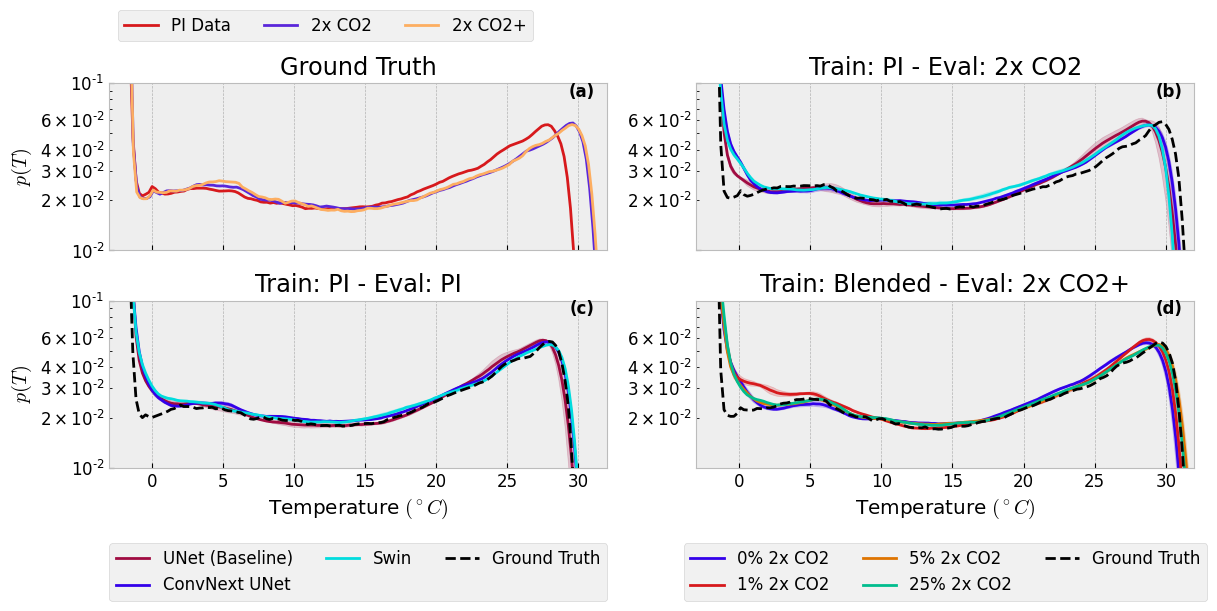

In [15]:
plot_temp_pdf(
    ['UNet (Baseline)', 'ConvNext UNet', 'Swin'],
    ['0% 2x CO2', '1% 2x CO2', '5% 2x CO2', '25% 2x CO2'],
    '_Long_',
    './temp/Figure1',
    pdf1,
    pdf2,
    pdf3,
    ground_pdfs,
)

### Noise Plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
nino_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/nino_true.npy')
nino_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/nino_saved.npy')
pdf1 = np.load("/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/pdf.npy", allow_pickle=True).item()

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric(axs, row, true_data, indices_data, network_names, y_label, title, blend_names=None, label=None):
    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]
    N_plot = true_data.shape[1]
    for i, indices_i in enumerate(indices_data):
        if indices_i is not None:
            label_name = f"{network_names[i]}" if blend_names is None else f"{blend_names[i]}"
            axs[row].plot(np.arange(1, N_plot + 1), indices_i.mean(axis=0), c=clist[i], label=label_name)
            axs[row].fill_between(np.arange(1, N_plot + 1), 
                                       indices_i.mean(axis=0) - indices_i.std(axis=0), 
                                       indices_i.mean(axis=0) + indices_i.std(axis=0),
                                       ls="-",
                                       color=clist[i],
                                       alpha=0.2)
            
    axs[row].plot(np.arange(1, N_plot + 1), true_data.mean(axis=0), "--k", label="Ground Truth")
    
    axs[row].set_title(title, fontsize="15")
    
    axs[row].set_xlabel(r"time $( days )$", fontsize="15")
     
    axs[row].set_ylabel(y_label, fontsize="15")
    
    # Add the label at the bottom right corner
    if label:
        axs[row].text(0.95, 0.95, label, ha='center', va='center', transform=axs[row].transAxes, fontsize=12, fontweight='bold')

def plot_pdf(ax, pdf, ind_plot, network_names, clist, ylabel=None, title=None, legend_loc=None, label=None):
    for i, network_name in enumerate(network_names):
        ax.semilogy(
            pdf[ind_plot][network_name][0].mean(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0),
            lw=2,
            color=clist[i],
            label=f"{network_name}",
        )
        ax.fill_between(
            pdf[ind_plot][network_name][0].mean(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0) - pdf[ind_plot][network_name][1].std(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0) + pdf[ind_plot][network_name][1].std(axis=0),
            color=clist[i],
            alpha=0.2,
        )
    ax.semilogy(*pdf[ind_plot]["true"], lw=2, c="k", ls='--', label="Ground Truth")
    ax.set_ylim([0.01, 0.1])
    ax.set_xlim([-3, 32])
    ax.set_ylabel(ylabel)
    ax.set_xlabel(r"Temperature $( ^\circ C )$")
    
    ax.set_title(title)
    if legend_loc:
        ax.legend(loc='upper center', bbox_to_anchor=(-0.6, +1.1, 1, 0.2), fancybox=True, ncol=5)
    
    # Add the label at the top right corner
    if label:
        ax.text(0.95, 0.95, label, ha='center', va='center', transform=ax.transAxes, fontsize=12, fontweight='bold')


def plot_both_region_based_metric(
    network_names,
    region,
    save_str,
    output_dir,
    true_nino1,
    indices_nino1,
    pdf,
    blend_names,
    JUPYTER_MODE=False):

    plt.style.use("bmh")
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={"width_ratios": [1, 1], "height_ratios": [1], "wspace": 0.27, "hspace": 0.05})

    labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

    plot_metric(axs, 0, true_nino1, indices_nino1, network_names, 'Nino 3.4 Index', '', blend_names[0], 'a)')
    plot_pdf(axs[1], pdf, 2, network_names, ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"], ylabel=r'$p(T)$', title='', legend_loc='upper center', label='b)')
    
    # plt.show()
    
    plt.savefig('./temp/Figure4/noise', bbox_inches="tight")
    plt.clf()

In [8]:
# Plotting ENSO
plot_both_region_based_metric(
    [ '0% Noise', '5% Noise', '25% Noise', '100% noise'],
    '_Long',
    '',
    './temp/Figure2',   
    nino_true1, nino_saved1,pdf1,
    ['100% noise', '0% Noise', '5% Noise', '25% Noise'],
    True,
)

<Figure size 1200x300 with 0 Axes>

## Appendix

### Bias Maps

In [80]:
import sys
sys.path.append('../src/')

In [81]:
from constants import INPT_VARS, EXTRA_VARS, OUT_VARS, GLOBAL_COMBINED_STATS
import hydra
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import logging

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

from utils.data_utils import (
    get_wet_mask,
    get_train_test_ranges,
    gen_data_in_test,
    gen_data_out_test,
    data_CNN_Lateral,
    data_CNN_Dynamic,
    gen_data_025_lateral,
    gen_data_global_new,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_mean,
    compute_var,
    compute_corrs_area,
    compute_rmse,
    compute_corrs,
    compute_KE,
    compute_time_spec,
    compute_ACC,
    compute_nino34,
    compute_amo,
    gen_KE_spectrum,
    gen_KE,
    gen_KE_range,
    gen_value_range,
    gen_enstrophy_spectrum,
    gen_enstrophy,
    compute_corrs_single,
    compute_ACC_single,
    compute_RMSE_single,
    compute_mean_single,
)
from utils.subgrid_utils import get_area_tensor
from utils.climate_utils import compute_laplacian_wet
from utils.plot_utils import (
    plot_short_time_stats,
    plot_long_time_stats,
    plot_map,
    plot_error_map,
    plot_both_error_map,
    plot_metrics_KE_spectrum,
    plot_metrics_KE,
    plot_metrics_enstrophy_spectrum,
    plot_metrics_entrophy,
    plot_metrics_corr,
    plot_metrics_rmse,
    plot_metrics_acc,
    plot_metrics_mean,
    plot_metrics_pdf,
    get_initial_snapshot_fig,
    plot_region_based_metric,
    plot_diff_map,
)

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import copy
from datetime import datetime
import os

In [11]:
class Eval:
    def __init__(self, args):
        # Getting input, extra input and output
        self.inputs = INPT_VARS[args.exp_num_in]
        self.extra_in = EXTRA_VARS[args.exp_num_extra]
        self.outputs = OUT_VARS[args.exp_num_out]

        self.str_in = "".join([i + "_" for i in self.inputs])
        self.str_ext = "".join([i + "_" for i in self.extra_in])
        self.str_out = "".join([i + "_" for i in self.outputs])

        print("inputs: " + self.str_in)
        print("extra inputs: " + self.str_ext)
        print("outputs: " + self.str_out)

        self.N_atm = len(self.extra_in)  # Number of atmosphere variables
        self.N_in = len(self.inputs)
        if args.lateral:
            self.N_extra = (
                self.N_atm + self.N_in
            )  # Number of atmosphere variables + Lateral boundary variables
        else:
            self.N_extra = self.N_atm  # Number of atmosphere variables
        self.N_out = len(self.outputs)

        self.num_in = int((args.hist + 1) * self.N_in + self.N_extra)

        print("Number of inputs: ", self.num_in)  # 3 (ocean speeds + ocean temp)(t) +
        # 3 (atm wind stresses + atm temp)(t) +
        # 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
        print("Number of outputs: ", self.N_out)  # 3

        # Post-fix strings
        self.str_train = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_out
            + "N_train_4000"
            + "_Lateral_Data_025_no_smooth"
        )
        self.str_save = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_"
            + args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )
        self.post_model_name = (
            "Train_" + args.train_region
            + "_Test_" + args.region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_in
            + "N_train_"
            + str(args.N_samples)
            + "_Lateral_Data_025_no_smooth"
        )
        self.post_pred_name = (
            args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )

        # Getting start and end indices of train and test
        s_train, e_train, e_test = get_train_test_ranges(
            args.N_samples, args.N_val, args.lag, args.hist, args.interval
        )

        # Saving data
        print("Getting inputs")
        if "global_1" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag)
        elif "global_2x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="2x")
        elif "global_4x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="4x")
        else:
            raise NotImplementedError

        print("Calculating mask tensors")
        self.wet, self.wet_nan = get_wet_mask(inputs, "cpu")
        self.wet_bool = np.array(self.wet.cpu()).astype(bool)
        wet_lap = compute_laplacian_wet(self.wet_nan, 4) # hardcoded
        wet_lap = xr.where(wet_lap == 0, 1, np.nan)
        self.wet_lap = np.nan_to_num(wet_lap)
        print("Wet resolution:", self.wet.shape)

        self.time_vec = inputs[0].time.data

        self.time_test = self.time_vec[e_test : (e_test + args.lag * args.N_test)]

        print("Loading Train data")
        train_data = torch.load(
                    Path(args.data_dir) / "train_data_cnn_{0}.pt".format(self.str_train),
                    map_location=torch.device("cpu"),
                )
        self.train_data = train_data
    
        if args.save_test_data:
            print("Saving data")
            data_in_test = gen_data_in_test(
                0, e_test, args.N_test, args.lag, args.hist, inputs, extra_in
            )
            data_out_test = gen_data_out_test(
                0, e_test, args.N_test, args.lag, args.hist, outputs
            )
            if "global" in args.region:
                norm_vals = train_data.norm_vals
                if "combined" in args.train_region:
                    assert len(norm_vals) == len(GLOBAL_COMBINED_STATS) and all(np.array_equal(norm_vals[k], GLOBAL_COMBINED_STATS[k]) for k in norm_vals)
                self.test_data = data_CNN_Dynamic(
                    data_in_test,
                    data_out_test,
                    self.wet.to(device="cpu"),
                    norm_vals,
                    device=args.device,
                )
                # del train_data
            else:
                raise NotImplementedError()
            torch.save(
                self.test_data,
                Path(args.data_dir) / "test_data_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading test data")
            self.test_data = torch.load(
                Path(args.data_dir) / "test_data_cnn_{0}.pt".format(self.str_save)
            )

        # Model
        print("Loading model " + args.network)
        if "swin" in args.network.lower():
            model = instantiate(
                args.swin,
                in_channels=self.num_in,
                output_channels=self.N_in,
                pretrain_img_size=[*self.test_data[0][0].shape[1:]],
                wet=self.wet.cuda()
            )
        elif "unet" in args.network.lower():
            model = instantiate(
                args.unet, wet=self.wet.cuda()
            )

        full_model_path = args.ckpt_path
        self.full_model_name = args.network + "_" + self.post_model_name
        self.output_channels = model.output_channels

        model = model.to(args.device)
        self.ckpt_path = args.ckpt_path
        self.model = model

        # Stats
        self.mean_out = self.test_data.norm_vals["m_out"]
        self.std_out = self.test_data.norm_vals["s_out"]
        self.mean_in = self.test_data.norm_vals["m_in"]
        self.std_in = self.test_data.norm_vals["s_in"]

        # clim
        self.clim = None
        if args.save_clim_data:
            print("Saving clim")
            clim = np.zeros((366, *self.wet.shape, 3))
            for i in range(self.N_out):
                clim[:, :, :, i] = (
                    outputs[i].groupby("time.dayofyear").mean("time").data
                )
            torch.save(
                clim,
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading clim")
            clim = torch.load(
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save)
            )

        self.clim = clim

        # Getting area tensor
        print("Computing area tensor")
        self.grids = xr.open_dataset('/scratch/as15415/Data/CM2x_grids/Grid_New.nc').rename({"dx": "dxu", "dy": "dyu"})

        self.area = torch.from_numpy(self.grids["area_C"].to_numpy()).to(device="cpu")
        self.dx = self.grids["dxu"].to_numpy()
        self.dy = self.grids["dyu"].to_numpy()

        self.pred_model_path = Path(args.path_dir) / self.full_model_name
        if not os.path.isdir(self.pred_model_path):
            os.makedirs(self.pred_model_path)

        self.Nb = args.Nb
        self.hist = args.hist
        self.lag = args.lag
        self.N_test = args.N_test
        self.N_samples = args.N_samples
        self.output_dir = args.output_dir
        self.region = args.region
        self.steps = args.steps
        self.network = args.model_name_replace
        self.inputs = inputs

        self.pred_region = args.region
        self.pred_names = args.pred_names if args.pred_names else []
        self.pred_paths = args.pred_paths if args.pred_paths else []

        self.JUPYTER_MODE = False

    def send_data_to_cpu(self):
        self.test_data.set_device(device="cpu")

In [100]:
# G1 G1
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_swin_global", overrides=[
#         "output_dir=./temp/2024-05-24_swin_multiseed_g1g1".format(str(datetime.now())[:10]),
#         "model_name_replace=Swin",
#         "train_region=global_1",
#         "region=global_1",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=Swin Train1Eval1",
#         "swin.embed_dim=60",
#         "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
#         "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_swintrans60_global_1/swintrans60/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_seed100/swin/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_seed200/swin/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=['UNet (Baseline)', 'ConvNext UNet']",
#         "pred_paths=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/Adam UNet Train1Eval1_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth,\
#                     /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth]"
#     ])
#

# G1 G2x

with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_swin_global", overrides=[
        "output_dir=./temp/2024-05-23_swin_multiseed_g1g2x",
        "model_name_replace=Swin",
        "train_region=global_1",
        "region=global_2x",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=Swin Train1Eval2x",
        "swin.embed_dim=60",
        "exp/modules/blocks@swin.up_sampling_block=transposed_conv_upsample",
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_swintrans60_global_1/swintrans60/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_seed100/swin/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_swin_global_1_seed200/swin/saved_nets/swin_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['UNet (Baseline)', 'ConvNext UNet']",
        "pred_paths=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/Adam UNet Train1Eval2x_Train_global_1_Test_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth,\
                    /scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval2x_Train_global_1_Test_global_2x_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth]"
    ])
e = Eval(args)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs
Calculating mask tensors


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Wet resolution: torch.Size([180, 360])
Loading Train data
Loading test data
Loading model Swin Train1Eval2x
Loading clim
Computing area tensor


In [101]:

from pathlib import Path
network_names = e.pred_names + [e.network]
long_temp_true = np.load(Path(e.output_dir) / 'map_long_temp_true.npy')
long_KE_true = np.load(Path(e.output_dir) / 'map_long_KE_true.npy')
swapped_long_temp_RMSE_saved = np.load(Path(e.output_dir) / 'map_swapped_long_temp_RMSE_saved.npy')
swapped_long_mse_KE_saved = np.load(Path(e.output_dir) / 'map_swapped_long_mse_KE_saved.npy')


In [102]:
import matplotlib.ticker as mticker

def plot_both_error_map(network_names,
    region,
    save_str,
    output_dir,
    grids,
    Nb,
    wet_nan,
    long_KE_true,
    long_mse_KEs,
    long_T_true,
    long_mse_Ts,
    JUPYTER_MODE=False):

    plt.style.use("bmh")

    fig_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)']
    label_cnt = 0

    # Long KE
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(
        2,
        len(long_mse_Ts)+1,
        figsize=(20, 5),
        gridspec_kw={
            "width_ratios": [1] * (len(long_mse_Ts)+1),
            "height_ratios": [1, 1],
            "wspace": 0.15,
            "hspace": 0.001,
        },
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    # Ground Truth
    vmin = 0
    vmax = 100

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    axs[0, 0].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[0, 0].transAxes, fontsize=12, fontweight='bold')
    label_cnt +=1
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title(r"Ground Truth", size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.06,
        pos.y0 + 0.47,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Kinetic Energy $( J/m^2 )$", fontsize=15)
    fig.delaxes(cax)

    # Bias plots
    vmin = -20
    vmax = 20
    
    cmap = cmocean.cm.balance

    for i, long_mse_KE_i in enumerate(long_mse_KEs):
        if long_mse_KE_i is not None:
            if "global" in region:
                plt_n = axs[0, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[0, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[0, i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            axs[0, i+1].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[0, i+1].transAxes, fontsize=12, fontweight='bold')
            label_cnt +=1
            gl = axs[0, i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=False,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[0, i+1].set_title(network_names[i], size=15)

    pos = axs[0, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.08,
        pos.y0 + 0.47,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels
    cbar.ax.xaxis.set_label_position('top')

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Bias Kinetic Energy $( J/m^2 )$", fontsize=15)

    fig.delaxes(cax)
 
    ###### TEMP

    # Ground Truth
    vmin = -2
    vmax = 30

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[1, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    axs[1, 0].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[1, 0].transAxes, fontsize=12, fontweight='bold')
    label_cnt +=1
    gl = axs[1, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120])
    # axs[1, 0].set_title(r"Ground Truth", size=15)

    pos = axs[1, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.06,
        pos.y0 - 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Temperature $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    # Bias plots
    vmin = -2
    vmax = 2
    
    cmap = cmocean.cm.balance

    for i, long_mse_T_i in enumerate(long_mse_Ts):
        if long_mse_T_i is not None:
            if "global" in region:
                plt_n = axs[1, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[1, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[1, i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            axs[1, i+1].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[1, i+1].transAxes, fontsize=12, fontweight='bold')
            label_cnt +=1
            gl = axs[1, i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.left_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            # axs[1, i+1].set_title(network_names[i], size=15)

            gl.xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120])

    pos = axs[1, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle

    new_pos = [
        pos.x0 - 0.08,
        pos.y0 - 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Bias Temperature $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            './temp/Appendix/figures_bias/g1g2x',
            bbox_inches="tight",
        )
        plt.clf()

In [103]:

print("Plotting MAE temp map")
plot_both_error_map(
    network_names,
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    e.grids,
    e.Nb,
    e.wet_nan,
    long_KE_true,
    swapped_long_mse_KE_saved,
    long_temp_true,
    swapped_long_temp_RMSE_saved,
    False
)


Plotting MAE temp map


/state/partition1/job-46978390/ipykernel_809164/3624513661.py:102: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46978390/ipykernel_809164/3624513661.py:173: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46978390/ipykernel_809164/3624513661.py:254: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46978390/ip

<Figure size 2000x500 with 0 Axes>

### Timeseries plots

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [18]:
timeseries_KE_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/timeseries_KE_true.npy')
timeseries_KE_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/timeseries_KE_saved.npy')
timeseries_T_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/timeseries_T_true.npy')
timeseries_T_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_swin_multiseed_g1g1/timeseries_T_saved.npy')

timeseries_KE_true2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/timeseries_KE_true.npy')
timeseries_KE_saved2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/timeseries_KE_saved.npy')
timeseries_T_true2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/timeseries_T_true.npy')
timeseries_T_saved2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_swin_multiseed_g1g2x/timeseries_T_saved.npy')

timeseries_KE_true3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/timeseries_KE_true.npy')
timeseries_KE_saved3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/timeseries_KE_saved.npy')
timeseries_T_true3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/timeseries_T_true.npy')
timeseries_T_saved3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-23_convnext_blends_1p_seeds/timeseries_T_saved.npy')


In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric(axs, row, col, true_data, indices_data, network_names, y_label, title, blend_names=None, label=None):
    if col == 2:
        clist = ["#3300EA","#D7191C","#DE7400","#00BD8E"]
    else:
        clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]
    N_plot = true_data.shape[1]
    start = N_plot - 1001
    end = start + 1000
    for i, indices_i in enumerate(indices_data):
        if indices_i is not None:
            label_name = f"{network_names[i]}" if blend_names is None else f"{blend_names[i]}"
            axs[row, col].plot(np.arange(start, end), indices_i.mean(axis=0)[start:end], c=clist[i], label=label_name)
            axs[row, col].fill_between(np.arange(start, end), 
                                       indices_i.mean(axis=0)[start:end] - indices_i.std(axis=0)[start:end], 
                                       indices_i.mean(axis=0)[start:end] + indices_i.std(axis=0)[start:end],
                                       ls="-",
                                       color=clist[i],
                                       alpha=0.2)
            
    axs[row, col].plot(np.arange(start, end), true_data.mean(axis=0)[start:end], "--k", label="Ground Truth")
    if row == 0:
        axs[row, col].set_title(title, fontsize="14")
        axs[row, col].set_ylim([16,38])
    if row == 1:
        axs[row, col].set_xlabel(r"time $( days )$", fontsize="15")
        axs[row, col].set_ylim([16.6, 19.7])
    else:
        axs[row, col].tick_params(labelbottom=False)  # Remove x ticks in the first row
    if col == 0:
        axs[row, col].set_ylabel(y_label, fontsize="13.5")
    else:
        axs[row, col].tick_params(labelleft=False)  # Remove y ticks for columns except the first
    if row == 0 and col==0:
        axs[row, col].legend(bbox_to_anchor=(0, 1.2, 1, 0.2), loc="lower left", fancybox=True, fontsize="15", ncol=len(indices_data)+1)
    if row == 1 and col == 2:
        axs[row, col].legend(bbox_to_anchor=(-1.2, -0.8), loc="lower left", fancybox=True, fontsize="15", ncol=3)
    
    # Add the label at the bottom right corner
    if label:
        axs[row, col].text(0.95, 0.95, label, ha='center', va='center', transform=axs[row, col].transAxes, fontsize=12, fontweight='bold')

def plot_both_region_based_metric(
    network_names,
    region,
    save_str,
    output_dir,
    blend_names,
    JUPYTER_MODE=False):

    plt.style.use("bmh")
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(2, 3, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1, 1], "height_ratios": [1, 1], "wspace": 0.1, "hspace": 0.05})

    labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

    plot_metric(axs, 0, 0, timeseries_KE_true1*1.2e3, timeseries_KE_saved1*1.2e3, network_names, r"Kinetic Energy $( J/m^2 )$", "Train: PI - Eval: PI", label=labels[0])
    plot_metric(axs, 0, 1, timeseries_KE_true2*1.2e3, timeseries_KE_saved2*1.2e3, network_names, r"Kinetic Energy $( J/m^2 )$", "Train: PI - Eval: 2x CO2", label=labels[1])
    plot_metric(axs, 0, 2, timeseries_KE_true3*1.2e3, timeseries_KE_saved3*1.2e3, network_names, r"Kinetic Energy $( J/m^2 )$", "Train: Blended - Eval: 2x CO2+", blend_names, label=labels[2])

    plot_metric(axs, 1, 0, timeseries_T_true1, timeseries_T_saved1, network_names, r"Temperature $( ^\circ C )$", "Temperature", label=labels[3])
    plot_metric(axs, 1, 1, timeseries_T_true2, timeseries_T_saved2, network_names, r"Temperature $( ^\circ C )$", "Temperature", label=labels[4])
    plot_metric(axs, 1, 2, timeseries_T_true3, timeseries_T_saved3, network_names, r"Temperature $( ^\circ C )$", "Temperature", blend_names, label=labels[5])

    # plt.show()

    plt.savefig(Path(output_dir) / ('timeseries' + region + "_" + save_str + ".png"), bbox_inches="tight")
    plt.clf()

In [47]:
# Plotting
plot_both_region_based_metric(
    ['UNet (Baseline)', 'ConvNext UNet', 'Swin'],
    '',
    '',
    './temp/Appendix/timeseries',   
    ['0% 2x CO2', '25% 2x CO2', '5% 2x CO2', '1% 2x CO2'],
    False,
)

<Figure size 1200x500 with 0 Axes>

### Perturbation Plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
mean_T_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_perturbation/ConvNext UNet_mean_T_true.npy')
mean_T_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_perturbation/ConvNext UNet_mean_T_saved.npy')
mean_T_true2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_perturbation/Adam UNet_mean_T_true.npy')
mean_T_saved2 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_perturbation/Adam UNet_mean_T_saved.npy')
mean_T_true3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_perturbation/Swin_mean_T_true.npy')
mean_T_saved3 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-24_perturbation/Swin_mean_T_saved.npy')

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric(axs, row, true_data, indices_data, network_names, y_label, title, blend_names=None, label=None):

    clist = [cmocean.cm.oxy(.5),cmocean.cm.balance(.1),cmocean.cm.balance(.9)]
    
    N_plot = true_data.shape[1]
    start = N_plot - 1001
    end = start + 1000
    for i, indices_i in enumerate(indices_data):
        if indices_i is not None:
            label_name = f"{network_names[i]}" if blend_names is None else f"{blend_names[i]}"
            axs[row].plot(np.arange(start, end), indices_i.mean(axis=0)[start:end], c=clist[i], label=label_name)
            axs[row].fill_between(np.arange(start, end), 
                                       indices_i.mean(axis=0)[start:end] - indices_i.std(axis=0)[start:end], 
                                       indices_i.mean(axis=0)[start:end] + indices_i.std(axis=0)[start:end],
                                       ls="-",
                                       color=clist[i],
                                       alpha=0.2)

    if row !=0 :
        axs[row].tick_params(labelleft=False)
    axs[row].plot(np.arange(start, end), true_data.mean(axis=0)[start:end], "--k", label="Ground Truth")
    axs[row].set_title(title, fontsize="14")
    axs[row].set_xlabel(r"time $( days )$", fontsize="15")
    axs[row].set_ylim([15.8,18.7])
    if row == 0:
        axs[row].set_ylabel(y_label, fontsize="13.5")
        axs[row].legend(bbox_to_anchor=(0, 1.2, 1, 0.2), loc="lower left", fancybox=True, fontsize="15", ncol=3)
    
    # Add the label at the bottom right corner
    if label:
        axs[row].text(0.95, 0.95, label, ha='center', va='center', transform=axs[row].transAxes, fontsize=12, fontweight='bold')

def plot_both_region_based_metric(
    network_names,
    region,
    save_str,
    output_dir,
    blend_names,
    JUPYTER_MODE=False):

    plt.style.use("bmh")
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(1, 3, figsize=(12, 3), gridspec_kw={"width_ratios": [1, 1, 1], "height_ratios": [1], "wspace": 0.05, "hspace": 0.05})

    labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

    plot_metric(axs, 0, mean_T_true2, mean_T_saved2.squeeze(1) , network_names, r"Temperature $( ^\circ C )$", "UNet (Baseline)", label=labels[0])
    plot_metric(axs, 1, mean_T_true1, mean_T_saved1.squeeze(1), network_names, r"Temperature $( ^\circ C )$", "ConvNext UNet", label=labels[1])
    plot_metric(axs, 2, mean_T_true3, mean_T_saved3.squeeze(1) , network_names, r"Temperature $( ^\circ C )$", "Swin", label=labels[2])

    # plt.show()

    plt.savefig(Path(output_dir) / ('perturbation' + region + "_" + save_str + ".png"), bbox_inches="tight")
    plt.clf()

In [16]:
# Plotting
plot_both_region_based_metric(
    [r"0$^\circ C$ Perturbation", r"-1$^\circ C$ Perturbation", r"+1$^\circ C$ Perturbation"],
    '',
    '',
    './temp/Appendix/perturbation',   
    [],
    False,
)

<Figure size 1200x300 with 0 Axes>

### Noise Plots Appendix

#### Bias

In [1]:
import sys
sys.path.append('../src/')

from constants import INPT_VARS, EXTRA_VARS, OUT_VARS, GLOBAL_COMBINED_STATS
import hydra
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import logging

from utils.data_utils import (
    get_wet_mask,
    get_train_test_ranges,
    gen_data_in_test,
    gen_data_out_test,
    data_CNN_Lateral,
    data_CNN_Dynamic,
    gen_data_025_lateral,
    gen_data_global_new,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_mean,
    compute_var,
    compute_corrs_area,
    compute_rmse,
    compute_corrs,
    compute_KE,
    compute_time_spec,
    compute_ACC,
    compute_nino34,
    compute_amo,
    gen_KE_spectrum,
    gen_KE,
    gen_KE_range,
    gen_value_range,
    gen_enstrophy_spectrum,
    gen_enstrophy,
    compute_corrs_single,
    compute_ACC_single,
    compute_RMSE_single,
    compute_mean_single,
)
from utils.subgrid_utils import get_area_tensor
from utils.climate_utils import compute_laplacian_wet
from utils.plot_utils import (
    plot_short_time_stats,
    plot_long_time_stats,
    plot_map,
    plot_error_map,
    plot_both_error_map,
    plot_metrics_KE_spectrum,
    plot_metrics_KE,
    plot_metrics_enstrophy_spectrum,
    plot_metrics_entrophy,
    plot_metrics_corr,
    plot_metrics_rmse,
    plot_metrics_acc,
    plot_metrics_mean,
    plot_metrics_pdf,
    get_initial_snapshot_fig,
    plot_region_based_metric,
    plot_diff_map,
)

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import copy
from datetime import datetime
import os

class data_CNN_Dynamic(torch.utils.data.Dataset):

    def __init__(self, data_in, data_out, wet, area, noise_std, std_dict=None, device="cuda"):
        super().__init__()
        self.device = device
        num_inputs = data_in.shape[3]
        num_outputs = data_out.shape[3]
        self.size = data_in.shape[0]
        self.area = area
        self.noise_std = noise_std

        data_in = np.nan_to_num(data_in)
        data_out = np.nan_to_num(data_out)
        
        if std_dict is None:
            std_data = np.nanstd(data_in, axis=(0, 1, 2))
            mean_data = np.nanmean(data_in, axis=(0, 1, 2))
            std_label = np.nanstd(data_out, axis=(0, 1, 2))
            mean_label = np.nanmean(data_out, axis=(0, 1, 2))
        else:
            std_data = std_dict["s_in"]
            mean_data = std_dict["m_in"]
            std_label = std_dict["s_out"]
            mean_label = std_dict["m_out"]

        self.wet = wet

        for i in range(num_inputs):
            data_in[:, :, :, i] = (data_in[:, :, :, i] - mean_data[i]) / std_data[i]

        for i in range(num_outputs):
            data_out[:, :, :, i] = (data_out[:, :, :, i] - mean_label[i]) / std_label[i]

        data_in = torch.from_numpy(data_in).type(torch.float32).to(device="cpu")
        data_out = torch.from_numpy(data_out).type(torch.float32).to(device="cpu")

        std_dict = {
            "s_in": std_data,
            "s_out": std_label,
            "m_in": mean_data,
            "m_out": mean_label,
        }

        if wet == None:
            self.input = torch.swapaxes(torch.swapaxes(data_in, 1, 3), 2, 3)
            self.output = torch.swapaxes(torch.swapaxes(data_out, 1, 3), 2, 3)

        else:
            self.input = torch.mul(
                torch.swapaxes(torch.swapaxes(data_in, 1, 3), 2, 3), wet
            )
            self.output = torch.mul(
                torch.swapaxes(torch.swapaxes(data_out, 1, 3), 2, 3), wet
            )

        self.norm_vals = std_dict

    def set_device(self, device):
        self.device = device

    def __len__(self):
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return self.size

    def __getitem__(self, idx):
        # Return the idx-th data point of the dataset
        # If we have multiple things to return (data point and label), we can return them as tuple
        data_in = copy.deepcopy(self.input[idx])
        label = self.output[idx]

        # assert len(data_in.shape) == 3

        # for c in range(data_in.shape[0]):
        #     if c > 2:
        #         noise = torch.randn_like(data_in[c]) * self.noise_std
        #         assert noise.shape == self.area.shape
        #         noise = noise - (self.area * noise).sum() / self.area.sum()
        #         assert (self.area * noise).sum() / self.area.sum() < 1e-7
        #         data_in[c] = data_in[c] + noise
                    
        return data_in.to(device=self.device), label.to(device=self.device)


class Eval:
    def __init__(self, args, noise_std):
        # Getting input, extra input and output
        self.inputs = INPT_VARS[args.exp_num_in]
        self.extra_in = EXTRA_VARS[args.exp_num_extra]
        self.outputs = OUT_VARS[args.exp_num_out]

        self.str_in = "".join([i + "_" for i in self.inputs])
        self.str_ext = "".join([i + "_" for i in self.extra_in])
        self.str_out = "".join([i + "_" for i in self.outputs])

        print("inputs: " + self.str_in)
        print("extra inputs: " + self.str_ext)
        print("outputs: " + self.str_out)

        self.N_atm = len(self.extra_in)  # Number of atmosphere variables
        self.N_in = len(self.inputs)
        if args.lateral:
            self.N_extra = (
                self.N_atm + self.N_in
            )  # Number of atmosphere variables + Lateral boundary variables
        else:
            self.N_extra = self.N_atm  # Number of atmosphere variables
        self.N_out = len(self.outputs)

        self.num_in = int((args.hist + 1) * self.N_in + self.N_extra)

        print("Number of inputs: ", self.num_in)  # 3 (ocean speeds + ocean temp)(t) +
        # 3 (atm wind stresses + atm temp)(t) +
        # 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
        print("Number of outputs: ", self.N_out)  # 3

        # Post-fix strings
        self.str_train = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_out
            + "N_train_4000"
            + "_Lateral_Data_025_no_smooth"
        )
        self.str_save = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_"
            + args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )
        self.post_model_name = (
            "Train_" + args.train_region
            + "_Test_" + args.region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_in
            + "N_train_"
            + str(args.N_samples)
            + "_Lateral_Data_025_no_smooth"
        )
        self.post_pred_name = (
            args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )

        # Getting start and end indices of train and test
        s_train, e_train, e_test = get_train_test_ranges(
            args.N_samples, args.N_val, args.lag, args.hist, args.interval
        )

        # Saving data
        print("Getting inputs")
        if "global_1" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag)
        elif "global_2x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="2x")
        elif "global_4x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(self.inputs, self.extra_in, self.outputs, args.lag, run_type ="4x")
        else:
            raise NotImplementedError

        print("Calculating mask tensors")
        self.wet, self.wet_nan = get_wet_mask(inputs, "cpu")
        self.wet_bool = np.array(self.wet.cpu()).astype(bool)
        wet_lap = compute_laplacian_wet(self.wet_nan, 4) # hardcoded
        wet_lap = xr.where(wet_lap == 0, 1, np.nan)
        self.wet_lap = np.nan_to_num(wet_lap)
        print("Wet resolution:", self.wet.shape)

        self.time_vec = inputs[0].time.data

        self.time_test = self.time_vec[e_test : (e_test + args.lag * args.N_test)]

        # Getting area tensor
        print("Computing area tensor")
        self.grids = xr.open_dataset('/scratch/as15415/Data/CM2x_grids/Grid_New.nc').rename({"dx": "dxu", "dy": "dyu"})

        self.area = torch.from_numpy(self.grids["area_C"].to_numpy()).to(device="cpu")
        self.area /= self.area.max()
        self.dx = self.grids["dxu"].to_numpy()
        self.dy = self.grids["dyu"].to_numpy()

        print("Loading Train data")
        train_data = torch.load(
                    Path(args.data_dir) / "train_data_cnn_{0}.pt".format(self.str_train),
                    map_location=torch.device("cpu"),
                )
        self.train_data = train_data
    
        if args.save_test_data:
            print("Saving data")
            data_in_test = gen_data_in_test(
                0, e_test, args.N_test, args.lag, args.hist, inputs, extra_in
            )
            data_out_test = gen_data_out_test(
                0, e_test, args.N_test, args.lag, args.hist, outputs
            )
            if "global" in args.region:
                norm_vals = train_data.norm_vals
                if "combined" in args.train_region:
                    assert len(norm_vals) == len(GLOBAL_COMBINED_STATS) and all(np.array_equal(norm_vals[k], GLOBAL_COMBINED_STATS[k]) for k in norm_vals)
                self.test_data = data_CNN_Dynamic(
                    data_in_test,
                    data_out_test,
                    self.wet.to(device="cpu"),
                    self.area, 
                    noise_std,
                    norm_vals,
                    device=args.device,
                )
                # del train_data
            else:
                raise NotImplementedError()
            torch.save(
                self.test_data,
                Path(args.data_dir) / "test_{1}_data_cnn_{0}.pt".format(self.str_save, noise_std*100),
            )

        else:
            print("Loading test data")
            self.test_data = torch.load(
                Path(args.data_dir) / "test_{1}_data_cnn_{0}.pt".format(self.str_save, noise_std*100)
            )

        # Model
        print("Loading model " + args.network)
        if "swin" in args.network.lower():
            model = instantiate(
                args.swin,
                in_channels=self.num_in,
                output_channels=self.N_in,
                pretrain_img_size=[*self.test_data[0][0].shape[1:]],
                wet=self.wet.cuda()
            )
        elif "unet" in args.network.lower():
            model = instantiate(
                args.unet, wet=self.wet.cuda()
            )

        full_model_path = args.ckpt_path
        self.full_model_name = args.network + "_" + self.post_model_name
        self.output_channels = model.output_channels

        model = model.to(args.device)
        self.ckpt_path = args.ckpt_path
        self.model = model

        # Stats
        self.mean_out = self.test_data.norm_vals["m_out"]
        self.std_out = self.test_data.norm_vals["s_out"]
        self.mean_in = self.test_data.norm_vals["m_in"]
        self.std_in = self.test_data.norm_vals["s_in"]

        # clim
        self.clim = None
        if args.save_clim_data:
            print("Saving clim")
            clim = np.zeros((366, *self.wet.shape, 3))
            for i in range(self.N_out):
                clim[:, :, :, i] = (
                    outputs[i].groupby("time.dayofyear").mean("time").data
                )
            torch.save(
                clim,
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading clim")
            clim = torch.load(
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save)
            )

        self.clim = clim

        self.pred_model_path = Path(args.path_dir) / self.full_model_name
        if not os.path.isdir(self.pred_model_path):
            os.makedirs(self.pred_model_path)

        self.Nb = args.Nb
        self.hist = args.hist
        self.lag = args.lag
        self.N_test = args.N_test
        self.N_samples = args.N_samples
        self.output_dir = args.output_dir
        self.region = args.region
        self.steps = args.steps
        self.network = args.model_name_replace
        self.inputs = inputs

        self.pred_region = args.region
        self.pred_names = args.pred_names if args.pred_names else []
        self.pred_paths = args.pred_paths if args.pred_paths else []

        self.JUPYTER_MODE = False

    def send_data_to_cpu(self):
        self.test_data.set_device(device="cpu")


In [2]:
with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
    args = compose(config_name="exp/eval_unet_global", overrides=[
        "output_dir=./temp/{0}_conv_multiseed_g1g1_noise_fixed_100".format(str(datetime.now())[:10]),
        "model_name_replace=100% noise",
        "train_region=global_1",
        "region=global_1",
        "save_test_data=False",
        "run_gen_pred=False", # Multi-Seed Generation
        "network=ConvNext UNet Train1Eval1 100%Noise",
        "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed100/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed200/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
        "pred_names=['0% Noise', '5% Noise', '25% Noise']",
        "pred_paths=['/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1 5%Noise_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth',\
                    '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1 25%Noise_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth']"
    ])
swapped = True
e = Eval(args, noise_std=1.0)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Calculating mask tensors
Wet resolution: torch.Size([180, 360])
Computing area tensor
Loading Train data
Loading test data
Loading model ConvNext UNet Train1Eval1 100%Noise
Loading clim


In [93]:

from pathlib import Path
network_names = e.pred_names + [e.network]
# temp = network_names[1]
# network_names[1] = network_names[-1]
# network_names[-1] = temp
long_temp_true = np.load(Path(e.output_dir) / 'map_long_temp_true.npy')
long_KE_true = np.load(Path(e.output_dir) / 'map_long_KE_true.npy')
swapped_long_mse_KE_saved = np.load(Path(e.output_dir) / 'map_swapped_long_temp_RMSE_saved.npy')
swapped_long_temp_RMSE_saved = [swapped_long_temp_RMSE_saved[0],swapped_long_temp_RMSE_saved[3],swapped_long_temp_RMSE_saved[2],swapped_long_temp_RMSE_saved[1]]
swapped_long_mse_KE_saved = np.load(Path(e.output_dir) / 'map_swapped_long_mse_KE_saved.npy')
swapped_long_mse_KE_saved = [swapped_long_mse_KE_saved[0],swapped_long_mse_KE_saved[3],swapped_long_mse_KE_saved[2],swapped_long_mse_KE_saved[1]]

In [97]:

def plot_both_error_map(network_names,
    region,
    save_str,
    output_dir,
    grids,
    Nb,
    wet_nan,
    long_KE_true,
    long_mse_KEs,
    long_T_true,
    long_mse_Ts,
    JUPYTER_MODE=False):

    plt.style.use("bmh")

    fig_labels = ['a)', 'b)', 'c)', 'd)', 'e)', 'f)', 'g)', 'h)', 'i)', 'j)']
    label_cnt = 0

    # Long KE
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(
        2,
        len(long_mse_Ts)+1,
        figsize=(20, 5),
        gridspec_kw={
            "width_ratios": [1] * (len(long_mse_Ts)+1),
            "height_ratios": [1, 1],
            "wspace": 0.1,
            "hspace": 0.001,
        },
        subplot_kw={"projection": ccrs.PlateCarree()},
    )
    # Ground Truth
    vmin = 0
    vmax = 100

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[0, 0].pcolormesh(
            x_plot,
            y_plot,
            long_KE_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[0, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    gl = axs[0, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    axs[0, 0].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[0, 0].transAxes, fontsize=12, fontweight='bold')
    label_cnt +=1
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    axs[0, 0].set_title(r"Ground Truth", size=15)

    pos = axs[0, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.06,
        pos.y0 + 0.4,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Kinetic Energy $( J/m^2 )$", fontsize=15)
    fig.delaxes(cax)

    # Bias plots
    vmin = -20
    vmax = 20
    
    cmap = cmocean.cm.balance

    for i, long_mse_KE_i in enumerate(long_mse_KEs):
        if long_mse_KE_i is not None:
            if "global" in region:
                plt_n = axs[0, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[0, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_KE_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[0, i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            axs[0, i+1].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[0, i+1].transAxes, fontsize=12, fontweight='bold')
            label_cnt +=1
            gl = axs[0, i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=False,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            axs[0, i+1].set_title(network_names[i], size=15)

    pos = axs[0, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.06,
        pos.y0 + 0.4,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels
    cbar.ax.xaxis.set_label_position('top')

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Bias Kinetic Energy $( J/m^2 )$", fontsize=15)

    fig.delaxes(cax)
 
    ###### TEMP

    # Ground Truth
    vmin = -2
    vmax = 30

    if "global" in region:
        x_plot = grids["x_C"]
        y_plot = grids["y_C"]
    else:
        x_plot = grids["x_C"][Nb:-Nb, Nb:-Nb]
        y_plot = grids["y_C"][Nb:-Nb, Nb:-Nb]

    cmap = cmocean.cm.thermal  # cmocean.cm.diff

    # Ground Truth
    if "global" in region:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true * wet_nan,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )
    else:
        plt0 = axs[1, 0].pcolormesh(
            x_plot,
            y_plot,
            long_T_true[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto",
        )

    axs[1, 0].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
    axs[1, 0].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[1, 0].transAxes, fontsize=12, fontweight='bold')
    label_cnt +=1
    gl = axs[1, 0].gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=2,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.yrotation = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    # axs[1, 0].set_title(r"Ground Truth", size=15)

    pos = axs[1, 0].get_position()

    # Set the new anchor point to be in the middle
    new_pos = [
        pos.x0 - 0.06,
        pos.y0 - 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Temperature $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    # Bias plots
    vmin = -2
    vmax = 2
    
    cmap = cmocean.cm.balance

    for i, long_mse_T_i in enumerate(long_mse_Ts):
        if long_mse_T_i is not None:
            if "global" in region:
                plt_n = axs[1, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i * wet_nan,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )
            else:
                plt_n = axs[1, i+1].pcolormesh(
                    x_plot,
                    y_plot,
                    long_mse_T_i[Nb:-Nb, Nb:-Nb] * wet_nan[Nb:-Nb, Nb:-Nb],
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    shading="auto",
                )

            axs[1, i+1].add_feature(cart.feature.LAND, zorder=100, edgecolor="k")
            axs[1, i+1].text(-0.05, 0.95, fig_labels[label_cnt], ha='center', va='center', transform=axs[1, i+1].transAxes, fontsize=12, fontweight='bold')
            label_cnt +=1
            gl = axs[1, i+1].gridlines(
                crs=ccrs.PlateCarree(),
                draw_labels=True,
                linewidth=2,
                color="gray",
                alpha=0.5,
                linestyle="--",
            )
            gl.top_labels = False
            gl.right_labels = False
            gl.left_labels = False
            gl.yrotation = False
            gl.xformatter = LONGITUDE_FORMATTER
            gl.yformatter = LATITUDE_FORMATTER
            # axs[1, i+1].set_title(network_names[i], size=15)

    pos = axs[1, len(long_mse_KEs)].get_position()

    # Set the new anchor point to be in the middle

    new_pos = [
        pos.x0 - 0.06,
        pos.y0 - 0.15,
        pos.width * 1.75,
        pos.height * 1.5,
    ]  # Adjust 0.2 as needed

    # Create a new axes with the adjusted position
    cax = fig.add_axes(new_pos)

    cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
    cbar.ax.tick_params(labelsize=16)  # Set the font size for tick labels

    cbar.set_ticks(
        [np.ceil(vmin), np.round((vmin + vmax) / 2), np.floor(vmax)]
    )  # cbar.set_ticks([vmin, 0, vmax])

    cbar.set_label(r"Bias Temperature $( ^\circ C )$", fontsize=15)

    fig.delaxes(cax)

    if JUPYTER_MODE:
        plt.show()
    else:
        plt.savefig(
            './temp/Appendix/figures_bias/bias_noise',
            bbox_inches="tight",
        )
        plt.clf()

In [98]:
network_names


print("Plotting MAE temp map")
plot_both_error_map(
    network_names,
    e.region + '_Long_',
    e.str_save,
    e.output_dir,
    e.grids,
    e.Nb,
    e.wet_nan,
    long_KE_true,
    swapped_long_mse_KE_saved,
    long_temp_true,
    swapped_long_temp_RMSE_saved,
    False
)


Plotting MAE temp map


/state/partition1/job-46984237/ipykernel_2480912/1135759848.py:100: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46984237/ipykernel_2480912/1135759848.py:171: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt_n, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46984237/ipykernel_2480912/1135759848.py:251: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(plt0, ax=cax, orientation="horizontal", aspect=10)
/state/partition1/job-46984237

<Figure size 2000x500 with 0 Axes>

#### Rest

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
from pathlib import Path
import numpy as np
import cartopy.crs as ccrs
import cartopy as cart
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [2]:
amo_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/amo_true.npy')
amo_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/amo_saved.npy')
pdf1 = np.load("/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/pdf.npy", allow_pickle=True).item()
timeseries_KE_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/timeseries_KE_true.npy')
timeseries_KE_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/timeseries_KE_saved.npy')
timeseries_T_true1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/timeseries_T_true.npy')
timeseries_T_saved1 = np.load('/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/temp/2024-05-25_conv_multiseed_g1g1_noise_fixed_100/timeseries_T_saved.npy')

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric(axs, row, col, true_data, indices_data, network_names, y_label, title, blend_names=None, label=None):
    clist = ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"]
    N_plot = true_data.shape[1]
    if row == 1 and col == 0:
        start = 0
        end = 2970
    else:
        start = N_plot - 1001
        end = start + 1000
    for i, indices_i in enumerate(indices_data):
        if indices_i is not None:
            label_name = f"{network_names[i]}" if blend_names is None else f"{blend_names[i]}"
            axs[row, col].plot(np.arange(start, end), indices_i.mean(axis=0)[start:end], c=clist[i], label=label_name)
            axs[row, col].fill_between(np.arange(start, end), 
                                       indices_i.mean(axis=0)[start:end] - indices_i.std(axis=0)[start:end], 
                                       indices_i.mean(axis=0)[start:end] + indices_i.std(axis=0)[start:end],
                                       ls="-",
                                       color=clist[i],
                                       alpha=0.2)
            
    axs[row, col].plot(np.arange(start, end), true_data.mean(axis=0)[start:end], "--k", label="Ground Truth")
    
    axs[row, col].set_title(title, fontsize="15")
    
    axs[row, col].set_xlabel(r"time $( days )$", fontsize="15")
    
    axs[row, col].set_ylabel(y_label, fontsize="15")

    if row ==0 and col == 0:
        axs[row, col].legend(loc='upper center', bbox_to_anchor=(0.4, +1.2, 1, 0.2), fancybox=True, ncol=5)
    
    # Add the label at the bottom right corner
    if label:
        axs[row, col].text(0.95, 0.95, label, ha='center', va='center', transform=axs[row, col].transAxes, fontsize=12, fontweight='bold')

def plot_pdf(ax, pdf, ind_plot, network_name, clist, ylabel=None, title=None, legend_loc=None, label=None):
    for i, network_name in enumerate(network_name):
        ax.semilogy(
            pdf[ind_plot][network_name][0].mean(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0),
            lw=2,
            color=clist[i],
            label=f"{network_name}",
        )
        ax.fill_between(
            pdf[ind_plot][network_name][0].mean(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0) - pdf[ind_plot][network_name][1].std(axis=0),
            pdf[ind_plot][network_name][1].mean(axis=0) + pdf[ind_plot][network_name][1].std(axis=0),
            color=clist[i],
            alpha=0.2,
        )
    ax.semilogy(*pdf[ind_plot]["true"], lw=2, c="k", ls='--', label="Ground Truth")
    ax.set_ylim(
                [
                    pdf[ind_plot]["true_pdf"].min(),
                    pdf[ind_plot]["true_pdf"].max(),
                ]
            )
    ax.set_xlim([0, 2500])
    ax.set_ylabel(ylabel)
    ax.set_xlabel(r"Kinetic Energy $( J/m^2 )$")
    
    ax.set_title(title)
    
    # Add the label at the top right corner
    if label:
        ax.text(0.95, 0.95, label, ha='center', va='center', transform=ax.transAxes, fontsize=12, fontweight='bold')


def plot_both_region_based_metric(
    network_names,
    region,
    save_str,
    output_dir,
    amo_true1,
    amo_saved1,
    pdf,
    blend_names,
    JUPYTER_MODE=False):

    plt.style.use("bmh")
    plt.rcParams.update({"font.size": 12})
    fig, axs = plt.subplots(2, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1], "height_ratios": [1, 1], "wspace": 0.27, "hspace": 0.4})

    labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

    plot_metric(axs, 0, 0, timeseries_KE_true1, timeseries_KE_saved1, network_names, r"Kinetic Energy $( J/m^2 )$", '', blend_names, 'a)')
    plot_metric(axs, 0, 1, timeseries_T_true1, timeseries_T_saved1, network_names, r"Temperature $( ^\circ C )$", '', blend_names, 'b)')
    plot_metric(axs, 1, 0, amo_true1, amo_saved1, network_names, 'AMO Index', '', blend_names, 'c)')
    plot_pdf(axs[1, 1], pdf, "KE", network_names, ["#A00B41", "#3300EA", "#00DCDE", "#A6BD00"], ylabel=r'$p(KE)$', title='', legend_loc='upper center', label='d)')
    
    plt.show()
    
    # plt.savefig('./temp/Appendix/noiseappendix', bbox_inches="tight")
    # plt.clf()

/state/partition1/job-47058258/ipykernel_2757817/189139809.py:56: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  ax.set_ylim(


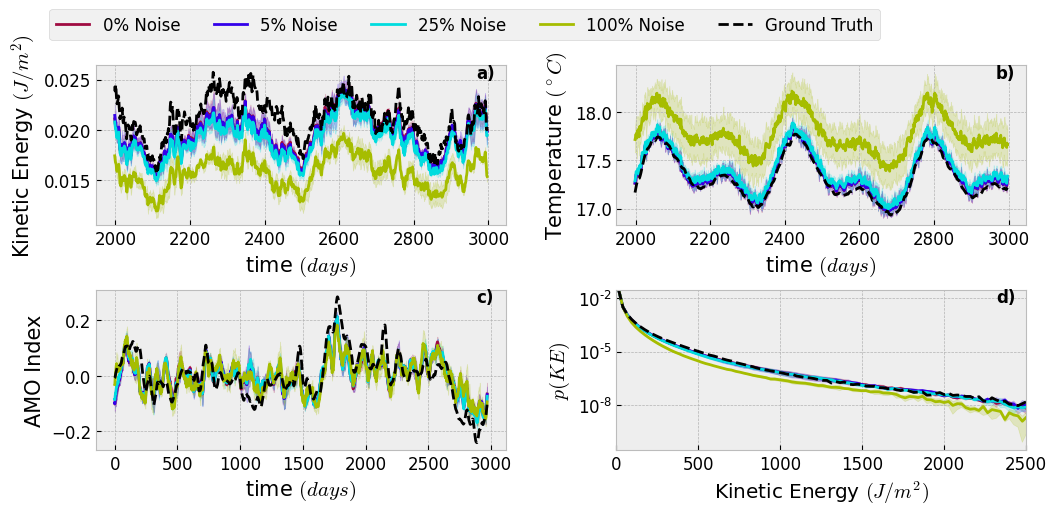

In [15]:
# Plotting
plot_both_region_based_metric(
    [ '0% Noise', '5% Noise', '25% Noise', '100% noise'],
    '_Long',
    '',
    './temp/Figure2',   
    amo_true1, amo_saved1,pdf1,
    ['0% Noise', '5% Noise', '25% Noise', '100% Noise'],
    True,
)